In [2]:
# Import library yang diperlukan
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, EfficientNetB0, DenseNet121, InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tarfile
import os
import gc
import time
import pandas as pd
from itertools import islice

# Set seed untuk reproduktibilitas
tf.random.set_seed(42)
np.random.seed(42)

In [5]:
# 1. Ekstraksi dataset CIFAR-10 dari cifar-10-python.tar.gz
def extract_cifar10_tar(tar_path, extract_path):
    """Mengekstrak file cifar-10-python.tar.gz ke folder tujuan."""
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)
        with tarfile.open(tar_path, 'r:gz') as tar:
            tar.extractall(extract_path)
        print(f"Dataset diekstrak ke: {extract_path}")
    else:
        print(f"Folder {extract_path} sudah ada, melewati ekstraksi.")

# Path ke file cifar-10-python.tar.gz
tar_path = '/content/drive/MyDrive/cifar-10-python.tar.gz'  # Sesuaikan dengan lokasi di Google Colab
extract_path = 'cifar-10-batches-py'

# Ekstrak file
extract_cifar10_tar(tar_path, extract_path)

Dataset diekstrak ke: cifar-10-batches-py


In [6]:
# 2. Memuat dataset CIFAR-10 dari file yang diekstrak
def load_cifar10_manual(data_path):
    """Memuat dataset CIFAR-10 dari file batch yang diekstrak."""
    train_data = []
    train_labels = []

    # Memuat batch pelatihan
    for batch in range(1, 6):
        batch_path = os.path.join(data_path, f'data_batch_{batch}')
        with open(batch_path, 'rb') as f:
            batch_data = pickle.load(f, encoding='bytes')
            train_data.append(batch_data[b'data'])
            train_labels.append(batch_data[b'labels'])

    # Menggabungkan data pelatihan
    x_train = np.concatenate(train_data, axis=0)
    y_train = np.concatenate(train_labels, axis=0)

    # Memuat batch pengujian
    test_path = os.path.join(data_path, 'test_batch')
    with open(test_path, 'rb') as f:
        test_data = pickle.load(f, encoding='bytes')
        x_test = test_data[b'data']
        y_test = np.array(test_data[b'labels'])

    # Reshape data ke format gambar (num_samples, 32, 32, 3)
    x_train = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    x_test = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return (x_train, y_train), (x_test, y_test)

# Memuat dataset
data_path = os.path.join(extract_path, 'cifar-10-batches-py')
(x_train, y_train), (x_test, y_test) = load_cifar10_manual(data_path)

# Mengurangi ukuran dataset agar tidak memakan waktu komputasi
train_samples = 2000
test_samples = 1000

# Mengambil subset secara acak
train_indices = np.random.choice(x_train.shape[0], train_samples, replace=False)
test_indices = np.random.choice(x_test.shape[0], test_samples, replace=False)

x_train = x_train[train_indices]
y_train = y_train[train_indices]
x_test = x_test[test_indices]
y_test = y_test[test_indices]

# Menampilkan informasi dasar dataset
print(f"Ukuran data pelatihan: {x_train.shape}, Label: {y_train.shape}")
print(f"Ukuran data pengujian: {x_test.shape}, Label: {y_test.shape}")

# Label kelas CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

Ukuran data pelatihan: (2000, 32, 32, 3), Label: (2000,)
Ukuran data pengujian: (1000, 32, 32, 3), Label: (1000,)


In [7]:
# 3. Preprocessing Citra dengan tf.data untuk efisiensi memori
IMG_SIZE = 224
BATCH_SIZE = 128  # Ukuran batch untuk memproses data

def preprocess_image(image, label):
    """Fungsi untuk resize dan normalisasi per gambar."""
    # Resizing ke 224x224
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Normalisasi ke [0, 1]
    image = image / 255.0
    return image, label

# Konversi data ke tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))

# Terapkan preprocessing secara bertahap
train_dataset = (train_dataset
                 .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

test_dataset = (test_dataset
                .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))

# Simpan dataset pengujian tanpa batch untuk visualisasi prediksi
test_dataset_unbatched = test_dataset.unbatch().shuffle(1000).take(1000)

# Verifikasi preprocessing dengan mengambil satu batch
for images, labels in train_dataset.take(1):
    print(f"Ukuran batch pelatihan setelah preprocessing: {images.shape}")
    print(f"Rentang nilai piksel (train): {tf.reduce_min(images).numpy()} - {tf.reduce_max(images).numpy()}")

for images, labels in test_dataset.take(1):
    print(f"Ukuran batch pengujian setelah preprocessing: {images.shape}")
    print(f"Rentang nilai piksel (test): {tf.reduce_min(images).numpy()} - {tf.reduce_max(images).numpy()}")

# Hapus variabel asli untuk menghemat memori
del x_train, x_test, y_train, y_test
gc.collect()

Ukuran batch pelatihan setelah preprocessing: (128, 224, 224, 3)
Rentang nilai piksel (train): 0.0 - 1.0
Ukuran batch pengujian setelah preprocessing: (128, 224, 224, 3)
Rentang nilai piksel (test): 0.0 - 1.0


0

In [8]:
# 4. Augmentasi Sederhana
datagen = ImageDataGenerator(
    rotation_range=15,          # Rotasi acak hingga 15 derajat
    width_shift_range=0.1,     # Pergeseran horizontal hingga 10%
    height_shift_range=0.1,    # Pergeseran vertikal hingga 10%
    horizontal_flip=True,       # Flip horizontal acak
    fill_mode='nearest'        # Mengisi piksel kosong dengan nilai terdekat
)

# Catatan: datagen akan digunakan saat pelatihan model, tidak memerlukan fit sekarang
# karena data sudah diproses dalam pipeline tf.data

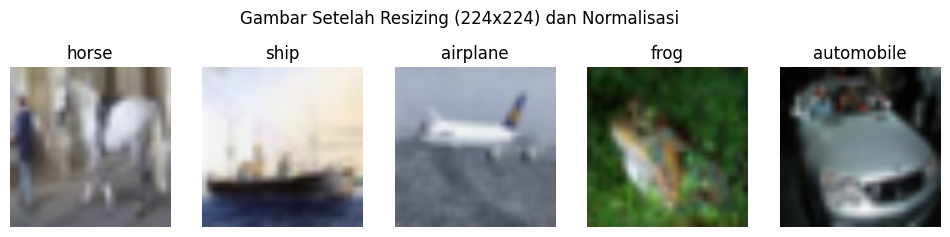

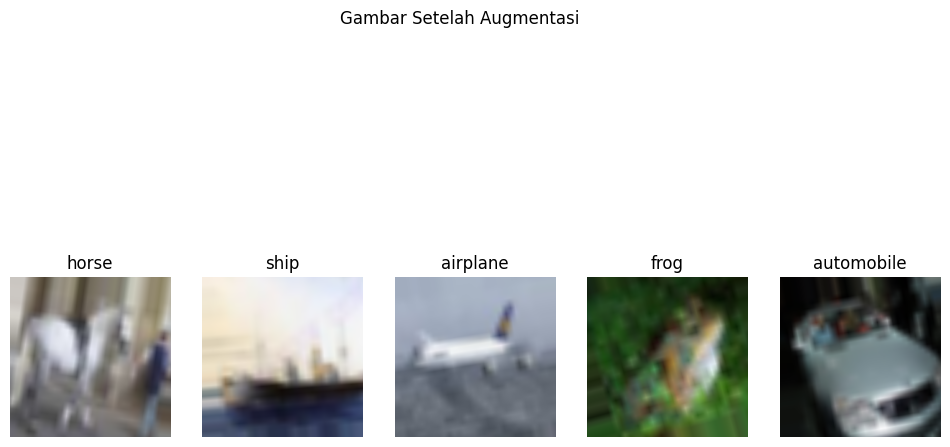

In [9]:
# 5. Visualisasi Data untuk Verifikasi
# Ambil beberapa sampel dari dataset untuk visualisasi
sample_dataset = train_dataset.unbatch().take(5)

plt.figure(figsize=(12, 5))
for i, (image, label) in enumerate(sample_dataset):
    plt.subplot(2, 5, i+1)
    plt.imshow(image.numpy())
    plt.title(class_names[label.numpy()])
    plt.axis('off')
plt.suptitle(f"Gambar Setelah Resizing ({IMG_SIZE}x{IMG_SIZE}) dan Normalisasi")
plt.show()

# Visualisasi augmentasi (contoh manual)
sample_images, sample_labels = next(iter(train_dataset.unbatch().take(5).batch(5)))
sample_images = sample_images.numpy()
sample_labels = sample_labels.numpy()

plt.figure(figsize=(12, 5))
for i, (img, label) in enumerate(datagen.flow(sample_images, sample_labels, batch_size=5, shuffle=False)):
    for j in range(5):
        plt.subplot(2, 5, j+6)
        plt.imshow(img[j])
        plt.title(class_names[int(sample_labels[j])])
        plt.axis('off')
    break
plt.suptitle("Gambar Setelah Augmentasi")
plt.show()

In [10]:
# 6. Implementasi Arsitektur CNN (Pretrained Models)
def build_vgg16_model(num_classes=10):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=predictions)

def build_resnet50_model(num_classes=10):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=predictions)

def build_mobilenetv2_model(num_classes=10):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=predictions)

def build_efficientnetb0_model(num_classes=10):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=predictions)

def build_densenet121_model(num_classes=10):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=predictions)

def build_inceptionv3_model(num_classes=10):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=predictions)

In [11]:
# Membangun model vgg16
vgg16_model = build_vgg16_model()

# Menampilkan ringkasan model vgg16
print("Ringkasan Model VGG16:")
vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Ringkasan Model VGG16:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
# Membangun model resnet50
resnet50_model = build_resnet50_model()

# Menampilkan ringkasan model resnet50
print("\nRingkasan Model ResNet50:")
resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Ringkasan Model ResNet50:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [13]:
# Membangun model mobilenetv2
mobilenetv2_model = build_mobilenetv2_model()

# Menampilkan ringkasan model mobilenetv2
print("\nRingkasan Model MobileNetV2:")
mobilenetv2_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Ringkasan Model MobileNetV2:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
# Membangun model efficientnetb0
efficientnetb0_model = build_efficientnetb0_model()

# Menampilkan ringkasan model efficientnetb0
print("\nRingkasan Model efficientnetb0:")
efficientnetb0_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Ringkasan Model efficientnetb0:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
# Membangun model densenet121
densenet121_model = build_densenet121_model()

# Menampilkan ringkasan model densenet121
print("\nRingkasan Model densenet121:")
densenet121_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Ringkasan Model densenet121:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,302,474 (27.86 MB)

 Trainable params: 264,970 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [16]:
# Membangun model inceptionv3
inceptionv3_model = build_inceptionv3_model()

# Menampilkan ringkasan model inceptionv3
print("\nRingkasan Model inceptionv3:")
inceptionv3_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Ringkasan Model inceptionv3:


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,329,898 (85.18 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [17]:
# 7. Pelatihan Model
EPOCHS = 10
LEARNING_RATE = 0.001

def train_model(model, model_name, train_ds, test_ds):
    """Fungsi untuk melatih, mengevaluasi, dan mengukur waktu."""
    # Kompilasi model
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Pengukuran waktu pelatihan
    start_time = time.time()
    print(f"\nMelatih model {model_name}...")
    history = model.fit(train_ds,
                       epochs=EPOCHS,
                       validation_data=test_ds,
                       verbose=1)
    training_time = time.time() - start_time
    avg_training_time_per_epoch = training_time / EPOCHS

    # Evaluasi
    print(f"\nEvaluasi model {model_name}...")
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    print(f"Akurasi pengujian {model_name}: {test_accuracy:.4f}")

    # Prediksi untuk metrik
    y_pred = []
    y_true = []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)

    # Classification report
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Pengukuran waktu inferensi
    inference_times = []
    for _ in range(5):  # Ulangi 5 kali untuk rata-rata
        start_inference = time.time()
        for images, _ in test_ds.take(1):
            model.predict(images, verbose=0)
        inference_times.append(time.time() - start_inference)
    avg_inference_time = np.mean(inference_times)

    # Hitung jumlah parameter dan ukuran model
    total_params = model.count_params()
    model_size_mb = sum(np.prod(v.shape) for v in model.trainable_variables) * 4 / (1024 ** 2)  # float32

    return history, test_accuracy, cm, avg_training_time_per_epoch, avg_inference_time, total_params, model_size_mb, precision, recall, f1_score

# Daftar model untuk pelatihan
models = [
    (vgg16_model, "VGG16"),
    (resnet50_model, "ResNet50"),
    (mobilenetv2_model, "MobileNetV2"),
    (efficientnetb0_model, "EfficientNetB0"),
    (densenet121_model, "DenseNet121"),
    (inceptionv3_model, "InceptionV3")
]

histories = {}
accuracies = {}
confusion_matrices = {}
training_times = {}
inference_times = {}
parameters = {}
model_sizes = {}
precisions = {}
recalls = {}
f1_scores = {}

# Melatih dan mengevaluasi setiap model
for model, model_name in models:
    history, accuracy, cm, train_time, infer_time, total_params, model_size, precision, recall, f1 = train_model(
        model, model_name, train_dataset, test_dataset)
    histories[model_name] = history
    accuracies[model_name] = accuracy
    confusion_matrices[model_name] = cm
    training_times[model_name] = train_time
    inference_times[model_name] = infer_time
    parameters[model_name] = total_params
    model_sizes[model_name] = model_size
    precisions[model_name] = precision
    recalls[model_name] = recall
    f1_scores[model_name] = f1
    gc.collect()


Melatih model VGG16...
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 111s 5s/step - accuracy: 0.1155 - loss: 2.4295 - val_accuracy: 0.2080 - val_loss: 2.2166
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 46s 846ms/step - accuracy: 0.1612 - loss: 2.2226 - val_accuracy: 0.3000 - val_loss: 2.1346
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 864ms/step - accuracy: 0.2347 - loss: 2.1189 - val_accuracy: 0.3320 - val_loss: 2.0650
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 810ms/step - accuracy: 0.2813 - loss: 2.0438 - val_accuracy: 0.3590 - val_loss: 1.9963
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 859ms/step - accuracy: 0.2987 - loss: 1.9782 - val_accuracy: 0.3830 - val_loss: 1.9380
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 791ms/step - accuracy: 0.3146 - loss: 1.9220 - val_accuracy: 0.4030 - val_loss: 1.8898
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 854ms/step - accuracy: 0.3240 - loss: 1.8667 - val_accuracy: 0.4020 - val_loss: 1.8463
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 802ms/step - accuracy: 0.3557 - l

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Melatih model MobileNetV2...
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.2720 - loss: 2.4011 - val_accuracy: 0.6490 - val_loss: 1.1119
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step - accuracy: 0.6256 - loss: 1.0913 - val_accuracy: 0.6850 - val_loss: 0.9458
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.7095 - loss: 0.8785 - val_accuracy: 0.7250 - val_loss: 0.8248
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.7442 - loss: 0.7416 - val_accuracy: 0.7380 - val_loss: 0.7839
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.7817 - loss: 0.6596 - val_accuracy: 0.7430 - val_loss: 0.7552
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.7979 - loss: 0.6002 - val_accuracy: 0.7490 - val_loss: 0.7398
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.8180 - loss: 0.5344 - val_accuracy: 0.7430 - val_loss: 0.7447
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.8365 - lo

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Melatih model DenseNet121...
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.2223 - loss: 2.3651 - val_accuracy: 0.6150 - val_loss: 1.3026
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 419ms/step - accuracy: 0.5442 - loss: 1.3167 - val_accuracy: 0.6830 - val_loss: 0.9959
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 396ms/step - accuracy: 0.6630 - loss: 1.0294 - val_accuracy: 0.7220 - val_loss: 0.8714
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 427ms/step - accuracy: 0.7084 - loss: 0.8949 - val_accuracy: 0.7330 - val_loss: 0.8250
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 408ms/step - accuracy: 0.7313 - loss: 0.7842 - val_accuracy: 0.7560 - val_loss: 0.7625
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 402ms/step - accuracy: 0.7460 - loss: 0.7379 - val_accuracy: 0.7550 - val_loss: 0.7335
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 432ms/step - accuracy: 0.7977 - loss: 0.6639 - val_accuracy: 0.7600 - val_loss: 0.7094
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 393ms/step - accuracy: 0.7938 - 

In [18]:
# 8. Analisis Kinerja
# a. Perbandingan Metrik Kinerja
comparison_data = {
    'Model': [],
    'Akurasi (%)': [],
    'Precision (%)': [],
    'Recall (%)': [],
    'F1-Score (%)': [],
    'Training Loss': [],
    'Validation Loss': []
}

for model_name in histories:
    comparison_data['Model'].append(model_name)
    comparison_data['Akurasi (%)'].append(accuracies[model_name] * 100)
    comparison_data['Precision (%)'].append(precisions[model_name] * 100)
    comparison_data['Recall (%)'].append(recalls[model_name] * 100)
    comparison_data['F1-Score (%)'].append(f1_scores[model_name] * 100)
    comparison_data['Training Loss'].append(histories[model_name].history['loss'][-1])
    comparison_data['Validation Loss'].append(histories[model_name].history['val_loss'][-1])

# Buat DataFrame untuk metrik kinerja
performance_df = pd.DataFrame(comparison_data)
print("\nTabel Perbandingan Metrik Kinerja:")
print(performance_df.to_string(index=False))


Tabel Perbandingan Metrik Kinerja:
         Model  Akurasi (%)  Precision (%)  Recall (%)  F1-Score (%)  Training Loss  Validation Loss
         VGG16    41.900000      42.870001        41.9     40.522048       1.758436         1.746395
      ResNet50    10.900000       2.900512        10.9      3.381016       2.300384         2.301097
   MobileNetV2    75.999999      76.385658        76.0     76.017258       0.418521         0.724831
EfficientNetB0     8.700000       0.756900         8.7      1.392640       2.302317         2.303335
   DenseNet121    76.400000      76.783867        76.4     76.440002       0.551248         0.666825
   InceptionV3    78.600001      80.231535        78.6     78.743013       0.339810         0.666975


In [19]:
# b. Perbandingan Efisiensi Komputasi
efficiency_data = {
    'Model': [],
    'Jumlah Parameter (juta)': [],
    'Ukuran Model (MB)': [],
    'Waktu Pelatihan per Epoch (detik)': [],
    'Waktu Inferensi per Batch (detik)': []
}

for model_name in histories:
    efficiency_data['Model'].append(model_name)
    efficiency_data['Jumlah Parameter (juta)'].append(parameters[model_name] / 1e6)
    efficiency_data['Ukuran Model (MB)'].append(model_sizes[model_name])
    efficiency_data['Waktu Pelatihan per Epoch (detik)'].append(training_times[model_name])
    efficiency_data['Waktu Inferensi per Batch (detik)'].append(inference_times[model_name])

# Buat DataFrame untuk efisiensi
efficiency_df = pd.DataFrame(efficiency_data)
print("\nTabel Perbandingan Efisiensi Komputasi:")
print(efficiency_df.to_string(index=False))


Tabel Perbandingan Efisiensi Komputasi:
         Model  Jumlah Parameter (juta)  Ukuran Model (MB)  Waktu Pelatihan per Epoch (detik)  Waktu Inferensi per Batch (detik)
         VGG16                14.848586            0.51078                          30.558517                           1.372736
      ResNet50                24.114826            2.01078                          14.215674                           0.896930
   MobileNetV2                 2.588490            1.26078                           7.621586                           0.321438
EfficientNetB0                 4.380077            1.26078                           8.912026                           0.435494
   DenseNet121                 7.302474            1.01078                          17.844526                           0.547925
   InceptionV3                22.329898            2.01078                          16.224066                           0.408585


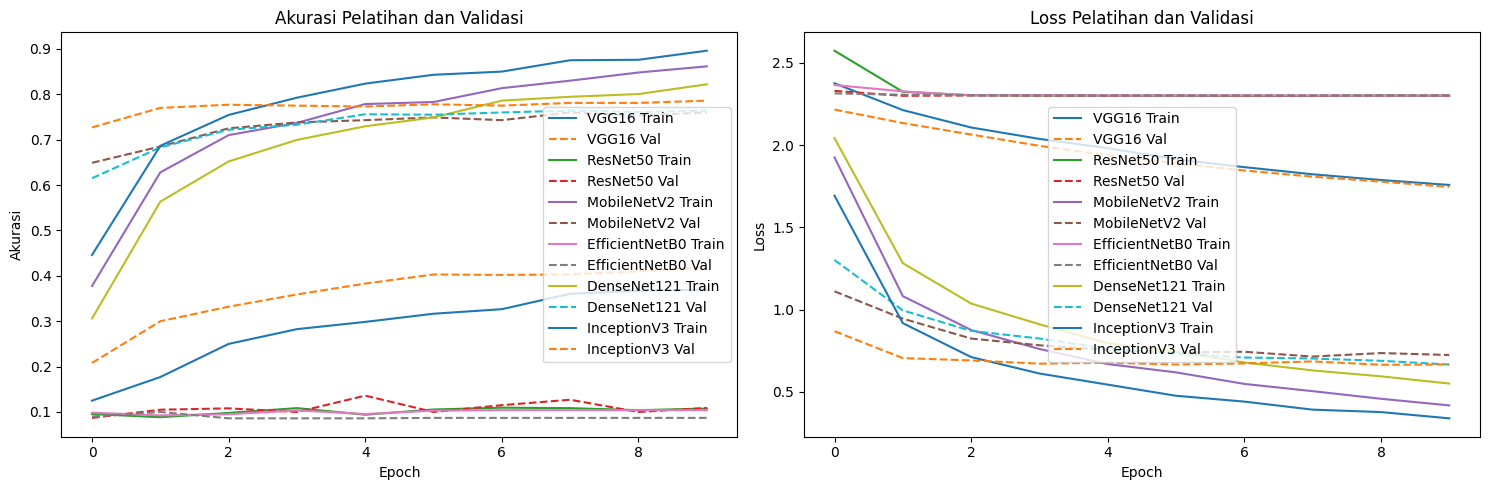

In [20]:
# 9. Visualisasi Perbandingan
# a. Akurasi dan Loss
plt.figure(figsize=(15, 5))

# Plot akurasi
plt.subplot(1, 2, 1)
for model_name in histories:
    plt.plot(histories[model_name].history['accuracy'], label=f'{model_name} Train')
    plt.plot(histories[model_name].history['val_accuracy'], linestyle='--', label=f'{model_name} Val')
plt.title('Akurasi Pelatihan dan Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
for model_name in histories:
    plt.plot(histories[model_name].history['loss'], label=f'{model_name} Train')
    plt.plot(histories[model_name].history['val_loss'], linestyle='--', label=f'{model_name} Val')
plt.title('Loss Pelatihan dan Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

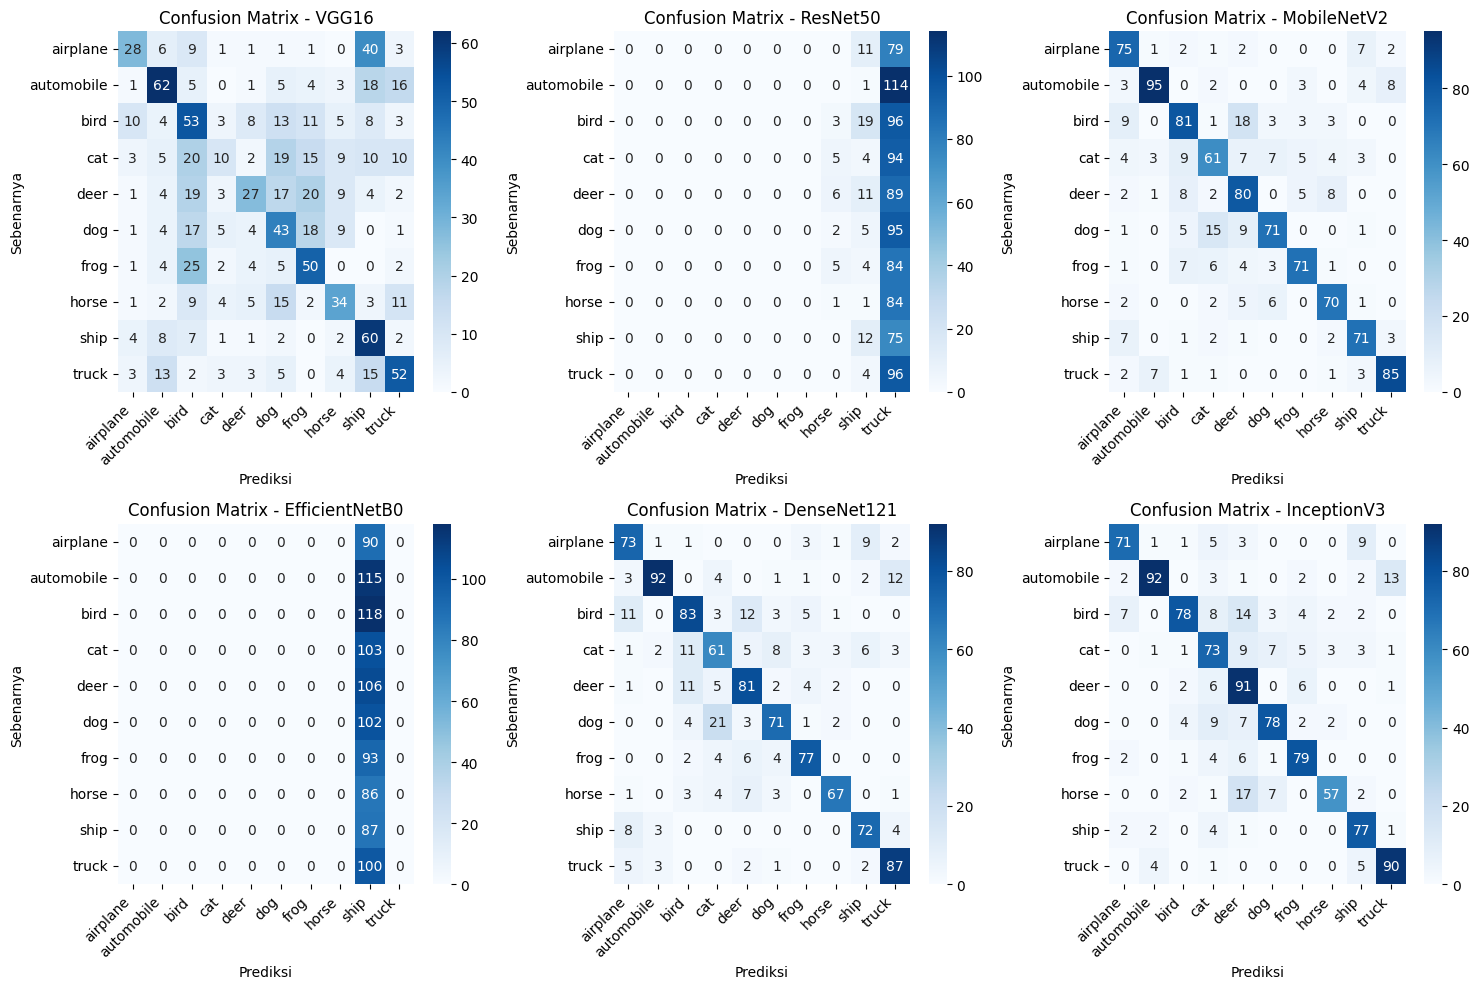

In [21]:
# b. Confusion Matrix untuk Setiap Model
plt.figure(figsize=(15, 10))
for i, (model_name, cm) in enumerate(confusion_matrices.items(), 1):
    plt.subplot(2, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=12)
    plt.xlabel('Prediksi', fontsize=10)
    plt.ylabel('Sebenarnya', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

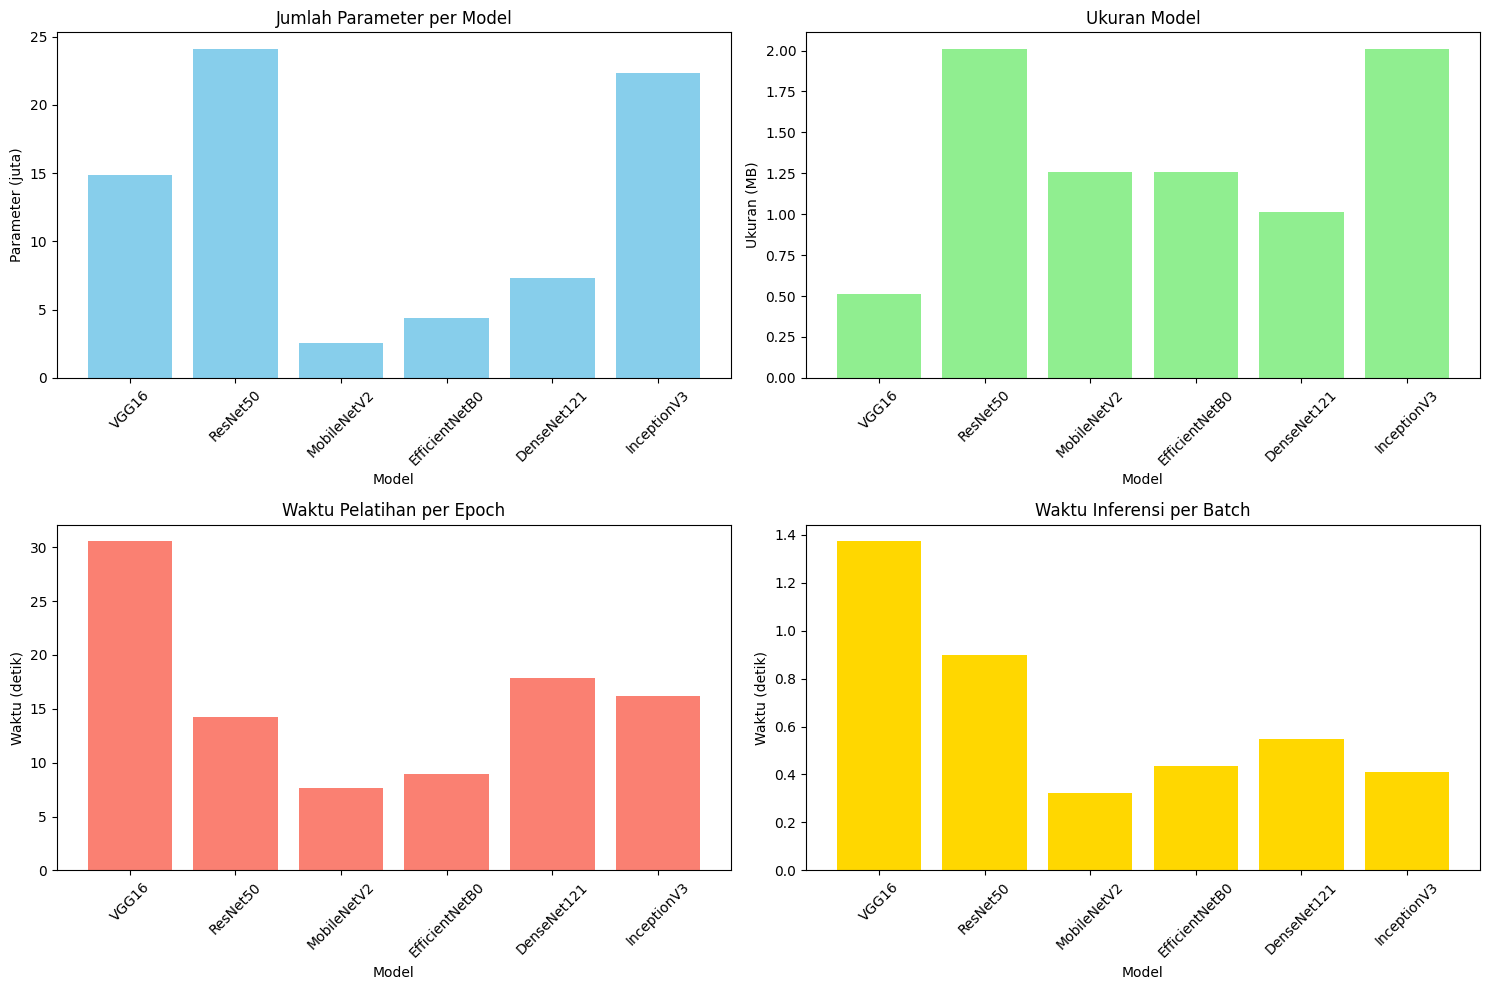

In [22]:
# c. Bar plot untuk efisiensi
plt.figure(figsize=(15, 10))

# Jumlah parameter
plt.subplot(2, 2, 1)
plt.bar(efficiency_df['Model'], efficiency_df['Jumlah Parameter (juta)'], color='skyblue')
plt.title('Jumlah Parameter per Model')
plt.xlabel('Model')
plt.ylabel('Parameter (juta)')
plt.xticks(rotation=45)

# Ukuran model
plt.subplot(2, 2, 2)
plt.bar(efficiency_df['Model'], efficiency_df['Ukuran Model (MB)'], color='lightgreen')
plt.title('Ukuran Model')
plt.xlabel('Model')
plt.ylabel('Ukuran (MB)')
plt.xticks(rotation=45)

# Waktu pelatihan
plt.subplot(2, 2, 3)
plt.bar(efficiency_df['Model'], efficiency_df['Waktu Pelatihan per Epoch (detik)'], color='salmon')
plt.title('Waktu Pelatihan per Epoch')
plt.xlabel('Model')
plt.ylabel('Waktu (detik)')
plt.xticks(rotation=45)

# Waktu inferensi
plt.subplot(2, 2, 4)
plt.bar(efficiency_df['Model'], efficiency_df['Waktu Inferensi per Batch (detik)'], color='gold')
plt.title('Waktu Inferensi per Batch')
plt.xlabel('Model')
plt.ylabel('Waktu (detik)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Model terbaik berdasarkan akurasi pengujian: InceptionV3 (0.7860)


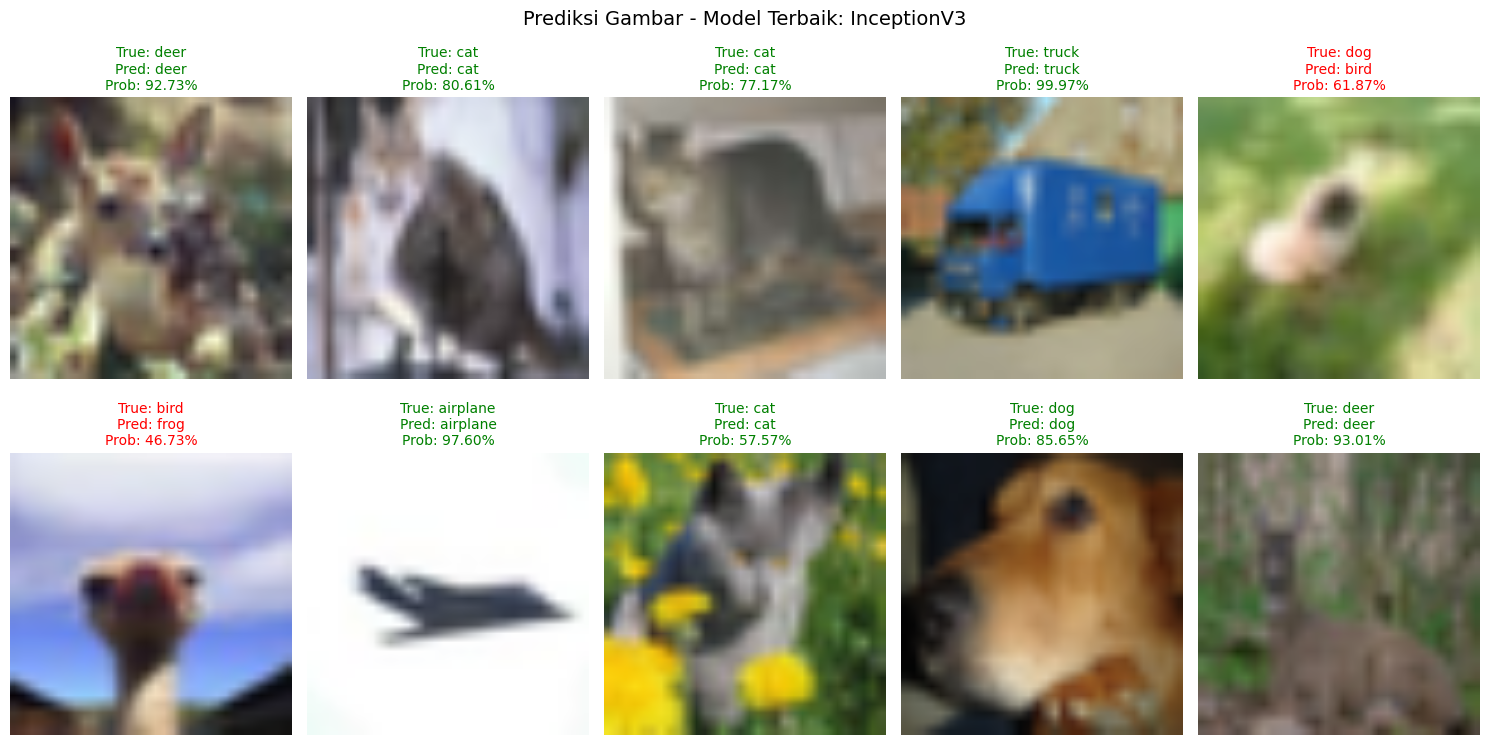

In [23]:
# d. Visualisasi Prediksi Model Terbaik
# Tentukan model terbaik berdasarkan akurasi pengujian
best_model_name = max(accuracies, key=accuracies.get)
best_model_accuracy = accuracies[best_model_name]
print(f"\nModel terbaik berdasarkan akurasi pengujian: {best_model_name} ({best_model_accuracy:.4f})")

# Pilih model terbaik
best_model = None
for model, model_name in models:
    if model_name == best_model_name:
        best_model = model
        break

# Ambil 10 gambar acak dari test_dataset untuk prediksi
np.random.seed(42)
sample_images = []
sample_labels = []
for img, lbl in test_dataset_unbatched.take(10):
    sample_images.append(img.numpy())
    sample_labels.append(lbl.numpy())

sample_images = np.array(sample_images)
sample_labels = np.array(sample_labels)

# Prediksi menggunakan model terbaik
predictions = best_model.predict(sample_images, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
prediction_probs = np.max(predictions, axis=1)

# Visualisasi prediksi
plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i])
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[predicted_classes[i]]
    prob = prediction_probs[i]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}\nProb: {prob:.2%}", color=color, fontsize=10)
    plt.axis('off')
plt.suptitle(f'Prediksi Gambar - Model Terbaik: {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()